# 多重共線性(Multicollinearity)

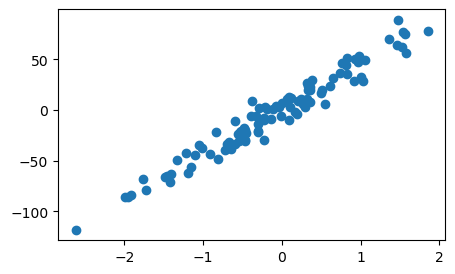

In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=100,n_features=1,noise = 10,random_state=42)
plt.figure(figsize=(5,3))
plt.scatter(X,y)
plt.show()

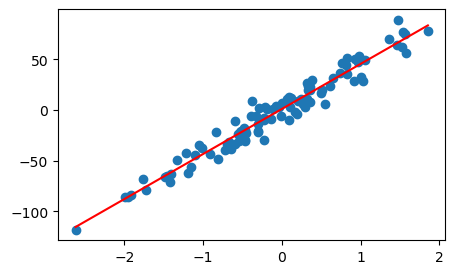

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)
myX = X.reshape(-1)
X_pred = np.linspace(np.min(myX),np.max(myX),20)
y_pred = X_pred * model.coef_[0] + model.intercept_
plt.figure(figsize=(5,3))
plt.scatter(X,y)
plt.plot(X_pred,y_pred,c="red")
plt.show()

In [8]:
model.coef_

array([44.43716999])

## 產生X的共線資料

In [11]:
X2 = X.copy()
X_new = np.hstack((X,X2))
X_new[:10]

array([[ 0.93128012,  0.93128012],
       [ 0.08704707,  0.08704707],
       [-1.05771093, -1.05771093],
       [ 0.31424733,  0.31424733],
       [-0.47917424, -0.47917424],
       [ 0.64768854,  0.64768854],
       [-0.46341769, -0.46341769],
       [ 0.54256004,  0.54256004],
       [ 0.61167629,  0.61167629],
       [ 1.0035329 ,  1.0035329 ]])

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_new,y)


LinearRegression()

In [14]:
model.coef_

array([22.218585, 22.218585])

In [ ]:
#無共線性
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1) 產生資料（只有 X 真的跟 y 有關）
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
rng = np.random.default_rng(42)
X2 = rng.normal(0,1,size=X.shape)
X_new = np.hstack([X,X2])

X_train,X_test,y_train,y_test = train_test_split(X_new,y,
                                                 test_size=0.4,random_state=42)
#X_train.shape,X_test.shape,y_train.shape,y_test.shape
rng_noise = np.random.default_rng(999)
X_test_noisy = X_test.copy()
#測試資料加了雜訊 0.3 越大 雜訊就越重
X_test_noisy[:,1] += rng_noise.normal(0,0.3,size= X_test[:,1].shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test_noisy)
mse = mean_squared_error(y_test,pred)
print(f"mse:{mse}")

mse:93.04900328109447


In [33]:
#無共線性
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1) 產生資料（只有 X 真的跟 y 有關）
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
rng = np.random.default_rng(42)
#產生共線性
X2 = X + rng.normal(0,0.001,size=X.shape)
X_new = np.hstack([X,X2])
X_train,X_test,y_train,y_test = train_test_split(X_new,y,
                                                 test_size=0.4,random_state=42)
#X_train.shape,X_test.shape,y_train.shape,y_test.shape
rng_noise = np.random.default_rng(999)
X_test_noisy = X_test.copy()
#測試資料加了雜訊 0.3 越大 雜訊就越重
X_test_noisy[:,1] += rng_noise.normal(0,0.3,size= X_test[:,1].shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test_noisy)
mse = mean_squared_error(y_test,pred)
print(f"mse:{mse}")

mse:196784.44621224003


In [58]:
import pandas as pd
data = pd.read_csv("BMI.csv")
data.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# variance_inflation_factor 算出的越大共線性就越強
data["Gender"] = data["Gender"].map({"Male":0,"Female":1})

X = data[["Gender","Height","Weight"]]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns


In [60]:
vif_data["VIF"] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]

In [61]:
vif_data

,feature,VIF
0,Gender,2.028864
1,Height,11.623103
2,Weight,10.688377


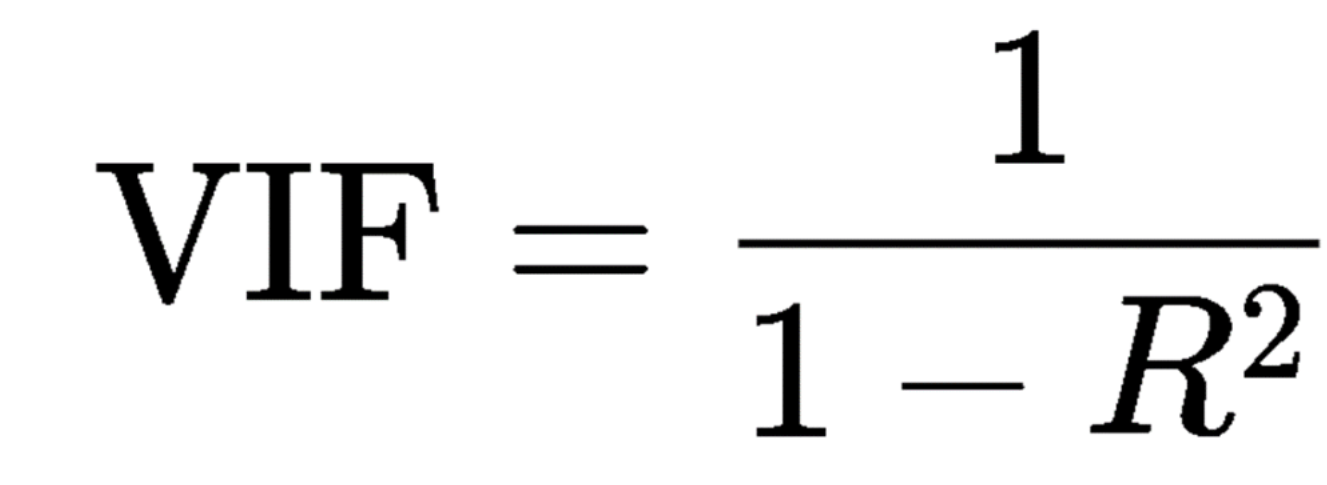

 **$(R^2)$**（R-squared）就是「**決定係數**」，

> 這個模型 **解釋了 y 的變動有多少比例**。

* $(R^2 = 0)$：幾乎**沒解釋到**（跟用平均值猜差不多）
* $(R^2 = 1)$：**完全解釋**（預測完美）
* 一般（有截距項時）會落在 0～1；有些特殊狀況（例如硬拿掉截距）也可能變成負的。

---

## $(R^2)$ 怎麼算（最常用公式）

$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$

### 兩個東西是什麼？

1. **$(SS_{tot})$**（總變動）
   $
   SS_{tot}=\sum (y_i-\bar{y})^2
   $
   意思：真實 y 跟「平均值 $(\bar y)$」的距離平方加總（y 本來就有多分散）

2. **$(SS_{res})$**（殘差變動/沒解釋到的誤差）
   $
   SS_{res}=\sum (y_i-\hat{y}_i)^2
  $
   意思：真實 y 跟「模型預測 $(\hat y)$」的距離平方加總（模型猜錯多少）

---

## 簡單範例（一步一步算）

假設真實值 y 有 4 筆：

* 真實 $(y)$：[10, 20, 30, 40]
* 模型預測 $(\hat y)$：[12, 18, 33, 37]

### Step 1：先算平均 $(\bar y)$

$
\bar y = (10+20+30+40)/4 = 25
$

### Step 2：算 $(SS_{tot})$

$
(10-25)^2=225
$
$
(20-25)^2=25
$
$
(30-25)^2=25
$
$
(40-25)^2=225
$
$
SS_{tot}=225+25+25+225=500
$

### Step 3：算 $(SS_{res})$

$
(10-12)^2=4
$
$
(20-18)^2=4
$
$
(30-33)^2=9
$
$
(40-37)^2=9
$
$
SS_{res}=4+4+9+9=26
$

### Step 4：算 $(R^2)$

$
R^2 = 1 - \frac{26}{500} = 1 - 0.052 = 0.948
$

✅ **答案：$(R^2 = 0.948)$**
模型大約解釋了 **94.8% 的 y 變動**，算是很不錯。

---

## VIF 公式有什麼關係？

你圖是：
$
VIF = \frac{1}{1-R^2}
$
這裡的 (R^2) 不是拿 y 去算，而是：

> **拿某一個特徵 (X_j)**，用「其他特徵」去回歸它，得到那次回歸的 (R^2)。

* $(R^2)$ 越接近 1：代表 $(X_j)$ 幾乎被其他特徵「解釋掉」→ 共線性越嚴重 → **VIF 會爆高**

如果你要，我也可以給你一個「兩個特徵算 VIF 的超小數字例子」，你會更直覺。


# Sequential Feature Selection(SFS)

In [62]:
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

## 載入資料

In [68]:
X,y = load_wine(return_X_y=True,as_frame=True)

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X.values,y,test_size=0.3,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((124, 13), (54, 13), (124,), (54,))

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [71]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_std,y_train)    

LogisticRegression()

In [72]:
clf.score(X_test_std,y_test)

0.9814814814814815

In [73]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
knn = KNeighborsClassifier(n_neighbors=11)
sfs = SequentialFeatureSelector(knn,n_features_to_select=3)
sfs.fit(X_train_std,y_train)
sfs.get_support()

array([False, False, False, False, False, False,  True, False, False,
        True, False, False,  True])

In [74]:
column_list = np.array(X.columns.to_list())
column_list[sfs.get_support()]

array(['flavanoids', 'color_intensity', 'proline'], dtype='<U28')

In [75]:
sfs.get_feature_names_out(column_list)

array(['flavanoids', 'color_intensity', 'proline'], dtype=object)

In [76]:
sfs.transform(X_train_std).shape

(124, 3)

In [78]:
clf = LogisticRegression()
clf.fit(sfs.transform(X_train_std),y_train)

LogisticRegression()

In [79]:
clf.score(sfs.transform(X_test_std),y_test)

0.9814814814814815